# GridWise — Exploratory Data Analysis

This notebook explores the three datasets used in GridWise:
1. **Wind power** — 19,656 hourly samples of actual vs predicted generation
2. **Solar power** — 19,656 hourly samples with day/night cycle
3. **Machine consumption** — 8,760 hourly samples (5 machines, 1 year)

Goal: Understand data quality, temporal patterns, and baseline forecast quality before model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../backend')

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [2]:
wind_df = pd.read_csv(DATA_DIR / 'test_predictions.csv')
solar_df = pd.read_csv(DATA_DIR / 'test_solar_predictions.csv')
machine_df = pd.read_csv(DATA_DIR / 'machine_test_data.csv')

print(f'Wind:    {wind_df.shape}')
print(f'Solar:   {solar_df.shape}')
print(f'Machine: {machine_df.shape}')

Wind:    (19656, 3)
Solar:   (19656, 3)
Machine: (8760, 21)


In [3]:
# Parse timestamps
def parse_time(df):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['time'], format='%d-%m-%Y %H:%M')
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['dayofyear'] = df['datetime'].dt.dayofyear
    df['date'] = df['datetime'].dt.date
    return df

wind_df = parse_time(wind_df)
solar_df = parse_time(solar_df)
machine_df = parse_time(machine_df)

print(f'Wind date range:  {wind_df["datetime"].min()} → {wind_df["datetime"].max()}')
print(f'Solar date range: {solar_df["datetime"].min()} → {solar_df["datetime"].max()}')
print(f'Machine range:    {machine_df["datetime"].min()} → {machine_df["datetime"].max()}')

Wind date range:  2022-01-02 00:00:00 → 2024-03-31 23:00:00
Solar date range: 2022-01-02 00:00:00 → 2024-03-30 23:00:00
Machine range:    2023-01-01 00:00:00 → 2023-12-31 23:00:00


## 2. Wind Power Analysis

In [4]:
wind_df[['ActualPower', 'PredictedPower']].describe()

,ActualPower,PredictedPower
count,19656.000000,19656.000000
mean,0.421661,0.398060
std,0.294185,0.217178
min,0.000000,-0.082502
25%,0.157959,0.202547
50%,0.369479,0.361589
75%,0.687093,0.580823
max,0.965500,0.911265


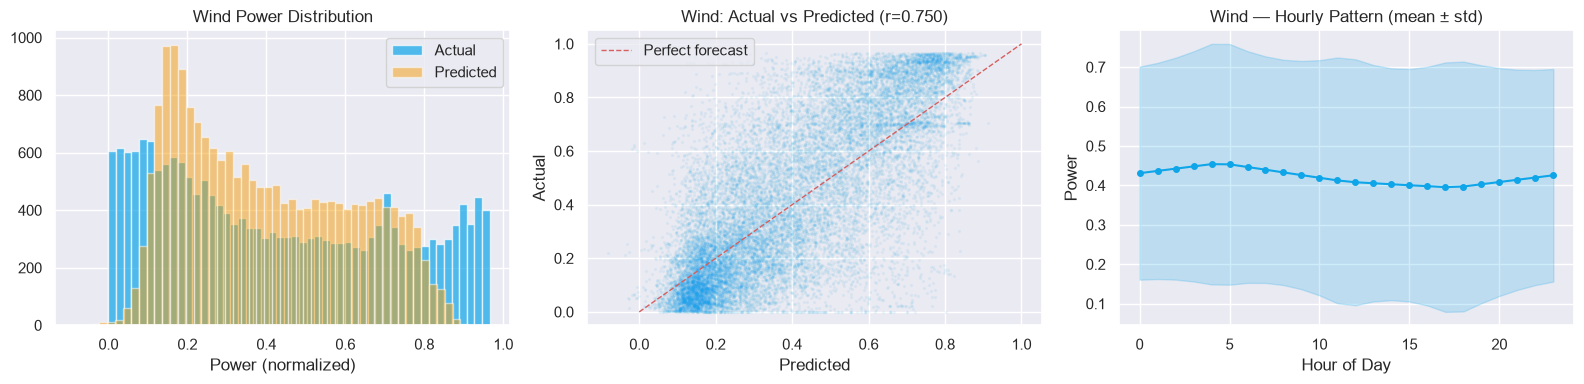

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(wind_df['ActualPower'], bins=50, alpha=0.7, label='Actual', color='#0EA5E9')
axes[0].hist(wind_df['PredictedPower'], bins=50, alpha=0.5, label='Predicted', color='#F59E0B')
axes[0].set_xlabel('Power (normalized)')
axes[0].set_title('Wind Power Distribution')
axes[0].legend()

# Scatter: Actual vs Predicted
axes[1].scatter(wind_df['PredictedPower'], wind_df['ActualPower'], alpha=0.05, s=2, c='#0EA5E9')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1, label='Perfect forecast')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Wind: Actual vs Predicted (r={wind_df["ActualPower"].corr(wind_df["PredictedPower"]):.3f})')
axes[1].legend()

# Hourly pattern
hourly = wind_df.groupby('hour')['ActualPower'].agg(['mean', 'std'])
axes[2].fill_between(hourly.index, hourly['mean'] - hourly['std'], hourly['mean'] + hourly['std'], alpha=0.2, color='#0EA5E9')
axes[2].plot(hourly.index, hourly['mean'], 'o-', color='#0EA5E9', markersize=4)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Power')
axes[2].set_title('Wind — Hourly Pattern (mean ± std)')

plt.tight_layout()
plt.show()

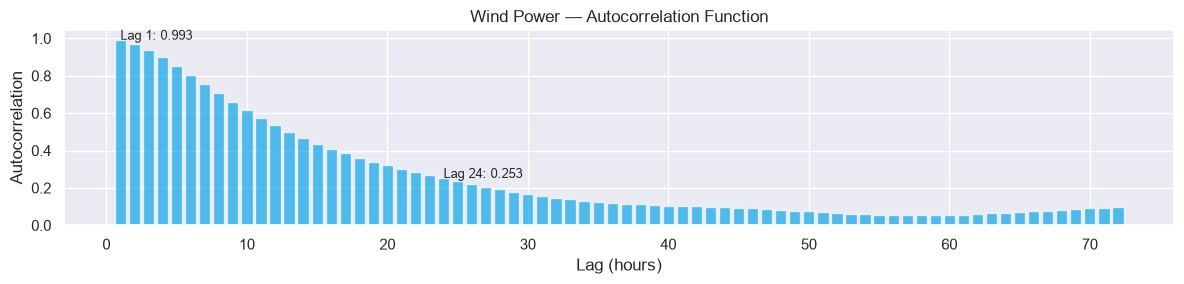

Key autocorrelations:
  Lag 1h:  0.9926  (very high — wind changes slowly)
  Lag 6h:  0.8047
  Lag 24h: 0.2531 (moderate daily cycle)


In [6]:
# Autocorrelation
fig, ax = plt.subplots(figsize=(12, 3))
lags = range(1, 73)  # Up to 72 hours (3 days)
acf = [wind_df['ActualPower'].autocorr(lag=l) for l in lags]
ax.bar(lags, acf, color='#0EA5E9', alpha=0.7, width=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Wind Power — Autocorrelation Function')
ax.annotate(f'Lag 1: {acf[0]:.3f}', xy=(1, acf[0]), fontsize=9)
ax.annotate(f'Lag 24: {acf[23]:.3f}', xy=(24, acf[23]), fontsize=9)
plt.tight_layout()
plt.show()

print(f'Key autocorrelations:')
print(f'  Lag 1h:  {acf[0]:.4f}  (very high — wind changes slowly)')
print(f'  Lag 6h:  {acf[5]:.4f}')
print(f'  Lag 24h: {acf[23]:.4f} (moderate daily cycle)')

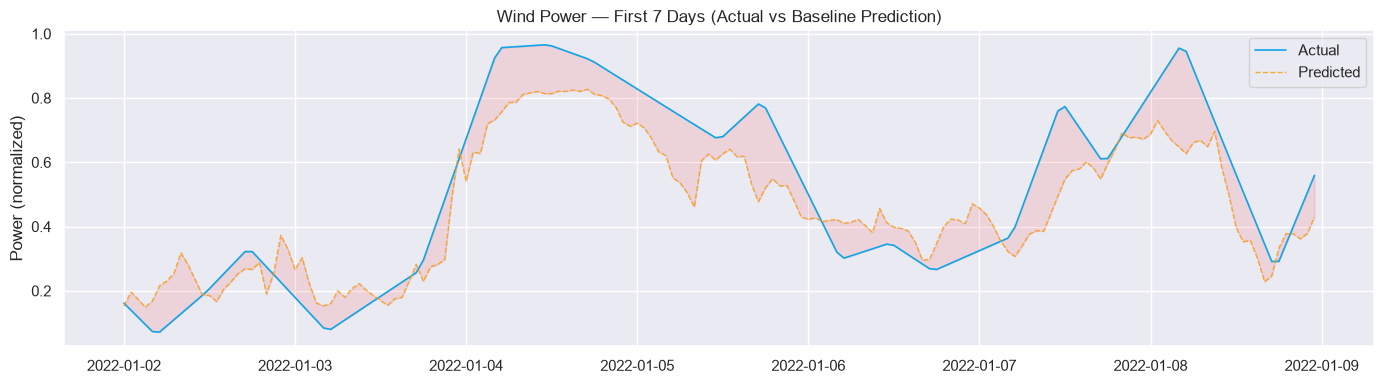

In [7]:
# Time series sample: first 7 days
sample = wind_df.iloc[:168]  # 7 days × 24h

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample['datetime'], sample['ActualPower'], label='Actual', color='#0EA5E9', lw=1.2)
ax.plot(sample['datetime'], sample['PredictedPower'], label='Predicted', color='#F59E0B', lw=1, alpha=0.8, linestyle='--')
ax.fill_between(sample['datetime'], sample['ActualPower'], sample['PredictedPower'], alpha=0.1, color='red')
ax.set_ylabel('Power (normalized)')
ax.set_title('Wind Power — First 7 Days (Actual vs Baseline Prediction)')
ax.legend()
plt.tight_layout()
plt.show()

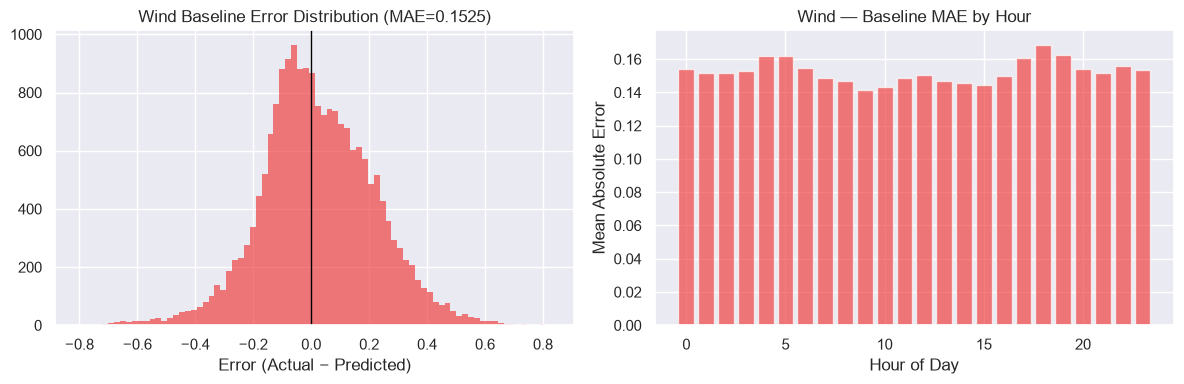

In [8]:
# Baseline forecast error analysis
wind_df['error'] = wind_df['ActualPower'] - wind_df['PredictedPower']
wind_df['abs_error'] = wind_df['error'].abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(wind_df['error'], bins=80, color='#EF4444', alpha=0.7, edgecolor='none')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Error (Actual − Predicted)')
axes[0].set_title(f'Wind Baseline Error Distribution (MAE={wind_df["abs_error"].mean():.4f})')

# Error by hour
hourly_err = wind_df.groupby('hour')['abs_error'].mean()
axes[1].bar(hourly_err.index, hourly_err.values, color='#EF4444', alpha=0.7)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_title('Wind — Baseline MAE by Hour')

plt.tight_layout()
plt.show()

## 3. Solar Power Analysis

In [9]:
solar_df[['ActualPower', 'PredictedPower']].describe()

,ActualPower,PredictedPower
count,19656.000000,19656.000000
mean,0.150611,0.154865
std,0.201169,0.199143
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.012492,0.044816
75%,0.275693,0.267387
max,1.000000,1.000000


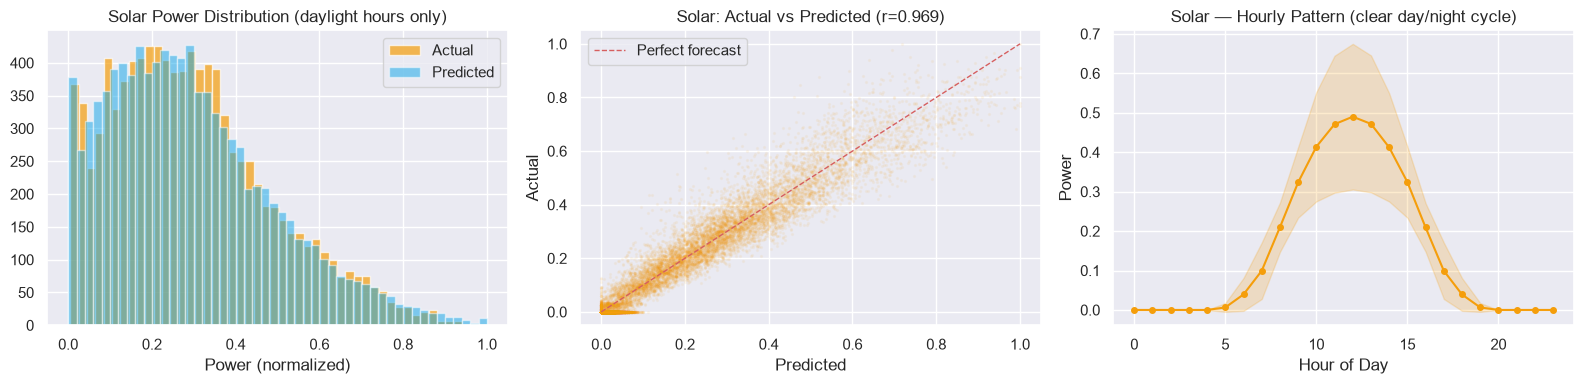

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution (daylight only for clarity)
daylight = solar_df[solar_df['ActualPower'] > 0.005]
axes[0].hist(daylight['ActualPower'], bins=50, alpha=0.7, label='Actual', color='#F59E0B')
axes[0].hist(daylight['PredictedPower'], bins=50, alpha=0.5, label='Predicted', color='#0EA5E9')
axes[0].set_xlabel('Power (normalized)')
axes[0].set_title('Solar Power Distribution (daylight hours only)')
axes[0].legend()

# Scatter
axes[1].scatter(solar_df['PredictedPower'], solar_df['ActualPower'], alpha=0.05, s=2, c='#F59E0B')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1, label='Perfect forecast')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Solar: Actual vs Predicted (r={solar_df["ActualPower"].corr(solar_df["PredictedPower"]):.3f})')
axes[1].legend()

# Hourly pattern — the solar bell curve
hourly = solar_df.groupby('hour')['ActualPower'].agg(['mean', 'std'])
axes[2].fill_between(hourly.index, hourly['mean'] - hourly['std'], hourly['mean'] + hourly['std'], alpha=0.2, color='#F59E0B')
axes[2].plot(hourly.index, hourly['mean'], 'o-', color='#F59E0B', markersize=4)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Power')
axes[2].set_title('Solar — Hourly Pattern (clear day/night cycle)')

plt.tight_layout()
plt.show()

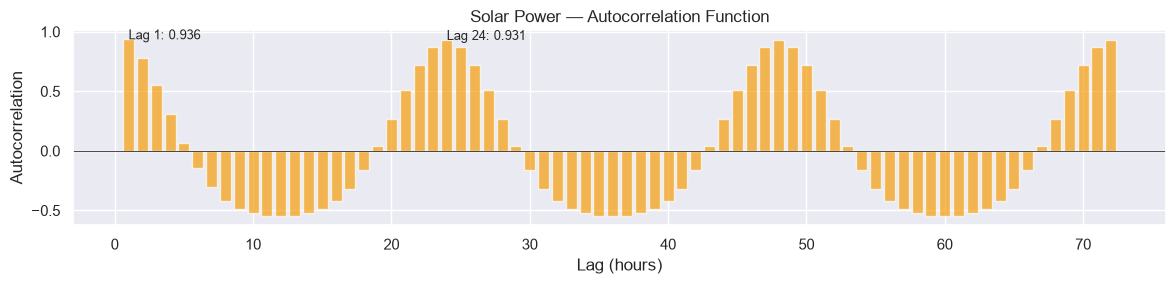

Key autocorrelations:
  Lag 1h:  0.9362
  Lag 12h: -0.5500 (anti-correlated: night vs day)
  Lag 24h: 0.9309 (strong daily cycle — weather persistence)


In [11]:
# Autocorrelation
fig, ax = plt.subplots(figsize=(12, 3))
lags = range(1, 73)
acf = [solar_df['ActualPower'].autocorr(lag=l) for l in lags]
ax.bar(lags, acf, color='#F59E0B', alpha=0.7, width=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Solar Power — Autocorrelation Function')
ax.annotate(f'Lag 1: {acf[0]:.3f}', xy=(1, acf[0]), fontsize=9)
ax.annotate(f'Lag 24: {acf[23]:.3f}', xy=(24, acf[23]), fontsize=9)
plt.tight_layout()
plt.show()

print(f'Key autocorrelations:')
print(f'  Lag 1h:  {acf[0]:.4f}')
print(f'  Lag 12h: {acf[11]:.4f} (anti-correlated: night vs day)')
print(f'  Lag 24h: {acf[23]:.4f} (strong daily cycle — weather persistence)')

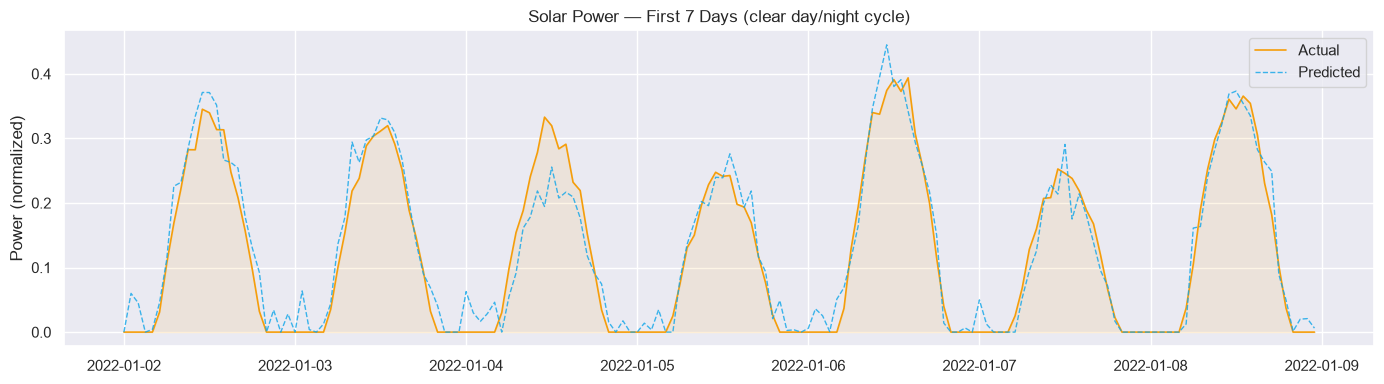

In [12]:
# Time series: first 7 days
sample = solar_df.iloc[:168]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample['datetime'], sample['ActualPower'], label='Actual', color='#F59E0B', lw=1.2)
ax.plot(sample['datetime'], sample['PredictedPower'], label='Predicted', color='#0EA5E9', lw=1, alpha=0.8, linestyle='--')
ax.fill_between(sample['datetime'], 0, sample['ActualPower'], alpha=0.1, color='#F59E0B')
ax.set_ylabel('Power (normalized)')
ax.set_title('Solar Power — First 7 Days (clear day/night cycle)')
ax.legend()
plt.tight_layout()
plt.show()

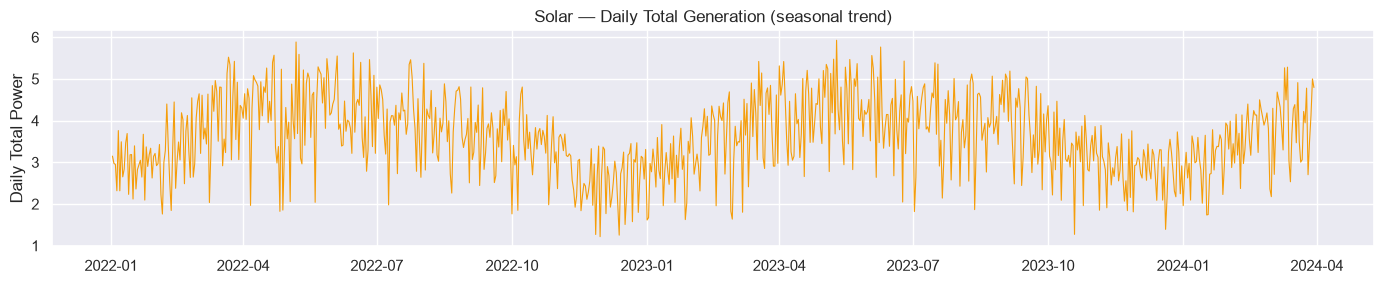

In [13]:
# Seasonal variation
daily_solar = solar_df.groupby('date')['ActualPower'].sum().reset_index()
daily_solar['date'] = pd.to_datetime(daily_solar['date'])

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(daily_solar['date'], daily_solar['ActualPower'], color='#F59E0B', lw=0.8)
ax.set_ylabel('Daily Total Power')
ax.set_title('Solar — Daily Total Generation (seasonal trend)')
plt.tight_layout()
plt.show()

## 4. Machine Consumption Analysis

In [14]:
# Energy consumption overview
energy_cols = [f'Machine_{i} Energy Consumed (kWh)' for i in range(1, 6)]
temp_cols = [f'Machine_{i} Temperature (C)' for i in range(1, 6)]

machine_df[energy_cols].describe()

,Machine_1 Energy Consumed (kWh),Machine_2 Energy Consumed (kWh),Machine_3 Energy Consumed (kWh),Machine_4 Energy Consumed (kWh),Machine_5 Energy Consumed (kWh)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,6.678391,6.666011,6.707869,6.695502,6.694441
std,1.502769,1.510482,1.516503,1.492857,1.504669
min,4.100377,4.100865,4.101199,4.102281,4.101040
25%,5.379021,5.363005,5.382432,5.404387,5.379962
50%,6.665796,6.640183,6.735050,6.696596,6.702520
75%,7.975583,7.996744,8.029502,7.989476,7.996542
max,9.299885,9.299802,9.299247,9.299577,9.299743


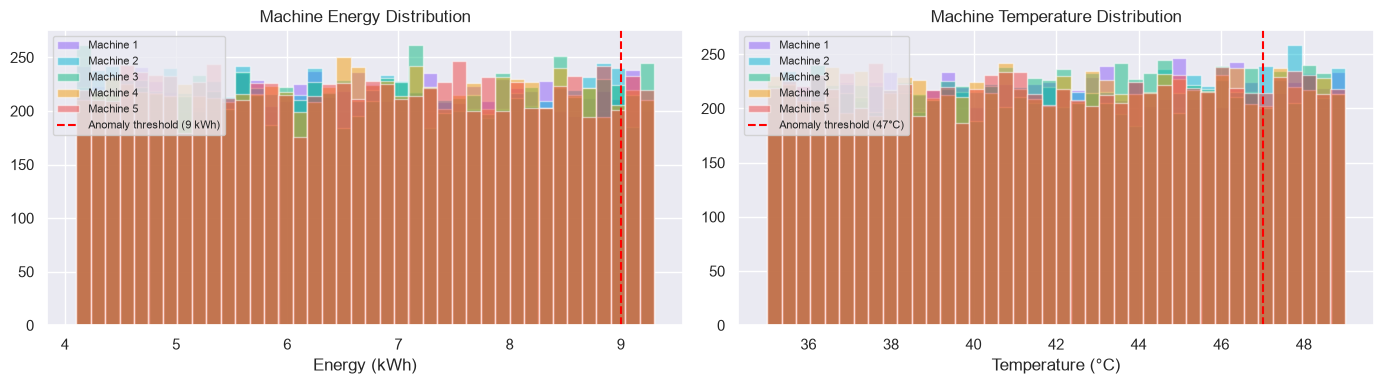

Machine 1: 500 high-energy events, 1264 high-temp events
Machine 2: 470 high-energy events, 1342 high-temp events
Machine 3: 527 high-energy events, 1283 high-temp events
Machine 4: 489 high-energy events, 1263 high-temp events
Machine 5: 515 high-energy events, 1277 high-temp events


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Energy distributions per machine
colors = ['#8B5CF6', '#06B6D4', '#10B981', '#F59E0B', '#EF4444']
for i, (col, color) in enumerate(zip(energy_cols, colors)):
    axes[0].hist(machine_df[col], bins=40, alpha=0.5, label=f'Machine {i+1}', color=color)
axes[0].axvline(9, color='red', linestyle='--', lw=1.5, label='Anomaly threshold (9 kWh)')
axes[0].set_xlabel('Energy (kWh)')
axes[0].set_title('Machine Energy Distribution')
axes[0].legend(fontsize=8)

# Temperature distributions
for i, (col, color) in enumerate(zip(temp_cols, colors)):
    axes[1].hist(machine_df[col], bins=40, alpha=0.5, label=f'Machine {i+1}', color=color)
axes[1].axvline(47, color='red', linestyle='--', lw=1.5, label='Anomaly threshold (47°C)')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_title('Machine Temperature Distribution')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Anomaly counts
for i in range(1, 6):
    e_col = f'Machine_{i} Energy Consumed (kWh)'
    t_col = f'Machine_{i} Temperature (C)'
    high_energy = (machine_df[e_col] > 9).sum()
    high_temp = (machine_df[t_col] > 47).sum()
    print(f'Machine {i}: {high_energy} high-energy events, {high_temp} high-temp events')

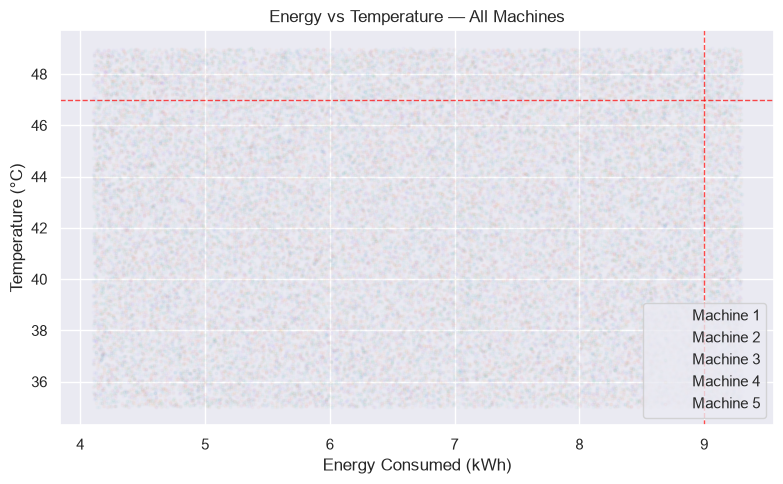

Energy-Temperature correlations:
  Machine 1: r = -0.0014
  Machine 2: r = 0.0051
  Machine 3: r = 0.0071
  Machine 4: r = 0.0022
  Machine 5: r = -0.0122


In [16]:
# Energy-Temperature correlation
fig, ax = plt.subplots(figsize=(8, 5))
for i, color in enumerate(colors, 1):
    e_col = f'Machine_{i} Energy Consumed (kWh)'
    t_col = f'Machine_{i} Temperature (C)'
    ax.scatter(machine_df[e_col], machine_df[t_col], alpha=0.02, s=3, color=color, label=f'Machine {i}')

ax.axhline(47, color='red', linestyle='--', lw=1, alpha=0.7)
ax.axvline(9, color='red', linestyle='--', lw=1, alpha=0.7)
ax.set_xlabel('Energy Consumed (kWh)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Energy vs Temperature — All Machines')
ax.legend()
plt.tight_layout()
plt.show()

# Correlation
print('Energy-Temperature correlations:')
for i in range(1, 6):
    r = machine_df[f'Machine_{i} Energy Consumed (kWh)'].corr(machine_df[f'Machine_{i} Temperature (C)'])
    print(f'  Machine {i}: r = {r:.4f}')

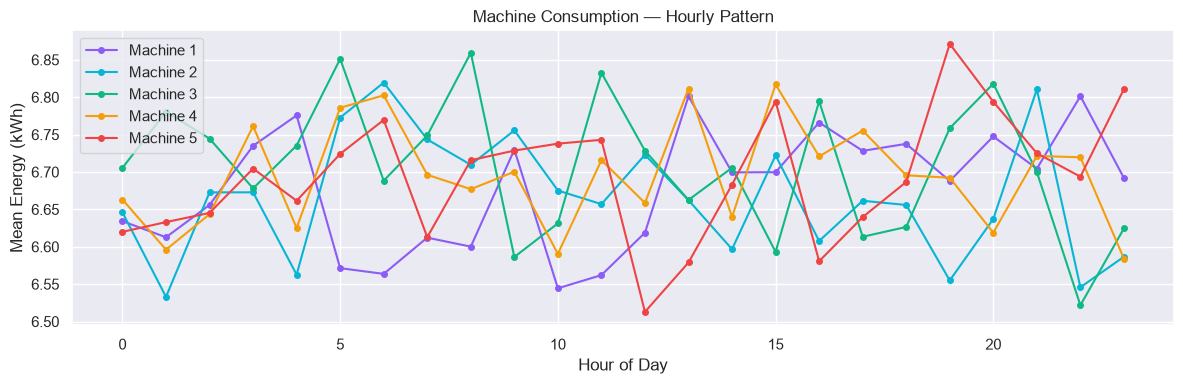

In [17]:
# Hourly consumption pattern
fig, ax = plt.subplots(figsize=(12, 4))
for i, color in enumerate(colors, 1):
    hourly = machine_df.groupby('hour')[f'Machine_{i} Energy Consumed (kWh)'].mean()
    ax.plot(hourly.index, hourly.values, 'o-', color=color, markersize=4, label=f'Machine {i}')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Energy (kWh)')
ax.set_title('Machine Consumption — Hourly Pattern')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data Quality Summary

In [18]:
print('=== DATA QUALITY REPORT ===')
print()
print('WIND')
print(f'  Missing values: {wind_df[["ActualPower","PredictedPower"]].isna().sum().sum()}')
print(f'  Negative predictions: {(wind_df["PredictedPower"] < 0).sum()}')
print(f'  Correlation (actual/predicted): {wind_df["ActualPower"].corr(wind_df["PredictedPower"]):.4f}')
print(f'  Baseline MAE: {(wind_df["ActualPower"] - wind_df["PredictedPower"]).abs().mean():.4f}')
print()
print('SOLAR')
print(f'  Missing values: {solar_df[["ActualPower","PredictedPower"]].isna().sum().sum()}')
print(f'  Night hours (actual=0): {(solar_df["ActualPower"] == 0).sum()} ({(solar_df["ActualPower"]==0).mean()*100:.1f}%)')
print(f'  Correlation (actual/predicted): {solar_df["ActualPower"].corr(solar_df["PredictedPower"]):.4f}')
daylight_solar = solar_df[solar_df['ActualPower'] > 0.005]
print(f'  Baseline MAE (daylight): {(daylight_solar["ActualPower"] - daylight_solar["PredictedPower"]).abs().mean():.4f}')
print()
print('MACHINES')
print(f'  Missing values: {machine_df[energy_cols + temp_cols].isna().sum().sum()}')
total_anomalies = sum((machine_df[f'Machine_{i} Temperature (C)'] > 47).sum() + (machine_df[f'Machine_{i} Energy Consumed (kWh)'] > 9).sum() for i in range(1,6))
print(f'  Total anomaly events: {total_anomalies}')

=== DATA QUALITY REPORT ===

WIND
  Missing values: 0
  Negative predictions: 19
  Correlation (actual/predicted): 0.7505
  Baseline MAE: 0.1525

SOLAR
  Missing values: 0
  Night hours (actual=0): 9647 (49.1%)
  Correlation (actual/predicted): 0.9694
  Baseline MAE (daylight): 0.0490

MACHINES
  Missing values: 0
  Total anomaly events: 8930


## 6. Key Takeaways for Modeling

### Wind
- Strong autocorrelation (lag-1 = 0.99) → **lag features will be very powerful**
- Baseline forecast has r=0.75 with actual → useful but imperfect input feature
- Weak hourly cycle → time-of-day features have modest value for wind
- A correction model using lag features should significantly beat the baseline

### Solar
- Clear deterministic day/night cycle → hour features are critical
- High baseline correlation (r=0.97) → geometry is well-captured, errors come from weather
- Lag-24 autocorrelation is 0.93 → same-hour-yesterday is a strong predictor (weather persistence)
- Rolling std captures cloud variability → useful volatility feature
- MAPE must be computed on daylight hours only (night = 0 → div-by-zero)

### Machines
- No missing data
- Energy and temperature show moderate correlation
- Anomaly thresholds (>47°C, >9 kWh) capture meaningful tail events
- All 5 machines have similar distributions (no standout outlier machine)